# <b> Objetivo </b> Demostrar que entendemos qué estamos prediciendo, con qué información, cómo está construido el dataset y qué restricciones debe respetar cualquier experimento posterior. 

```text
1. Definición del problema
   ├── 1.1 Target
   ├── 1.2 Estructura
   ├── 1.3 OOS setting
   └── 1.4 Information boundary

2. Inventario de datasets
   ├── 2.1 Dimensiones
   ├── 2.2 Columnas
   └── 2.3 Dtypes

3. Verificacion de la integridad de los datoa
   ├── 3.1 Unicidad de ID
   ├── 3.2 Correspondencia entre input y output
   ├── 3.3 Unicidad de (day, equity)
   ├── 3.4 Duplicados completos
   ├── 3.5 Valores infinitos
   ├── 3.6 Overlap de day
   ├── 3.7 Overlap de equity
   ├── 2.8 Overlap de ID
   └── Resumen de Integrity Checks


4. Verificacion de la integridad de los datoa
   ├── 4.1 Distribución global de reod
   ├── 4.2 baseline minimo
   ├── 4.3 Distribucion del tarjet por dia
   └── 4.4 conclusiones de la auditoria del target 

5. Calidad de datos y valores faltantes
   ├── 5.1 Magnitud global del missingness
   ├── 5.2 Dónde aparecen los NaN dentro de la sesión?
   ├── 5.3 Retorno cero ≠ NaN
   └── 5.4 Caracterizar el missingness por observación

   
```

## <b> 1. Definicion del problema </b>

El objetivo de este challenge es predecir el régimen direccional de una acción durante las últimas dos horas de la sesión de trading, utilizando únicamente la información observada durante las primeras 4.5 horas del mismo día.

Cada observación corresponde a un par único `(day, equity)`.

Para una acción $i$ en el día $d$, la información disponible consiste en una secuencia de 53 retornos consecutivos de 5 minutos observados entre las 09:30 y las 14:00:

$$
X_{i,d} =
\left[
r_{i,d,0},
r_{i,d,1},
\dots,
r_{i,d,52}
\right]
$$

donde cada retorno se encuentra expresado en puntos base (basis points, bps):

$$
r_{i,d,t}
=
\frac{P_{t+5min}-P_t}{P_t}\times 10^4
$$

Por lo tanto, la entrada del modelo representa la **trayectoria intradía del precio observada hasta las 14:00**, y no simplemente una observación puntual del activo.

### 1.1 Variable objetivo

La variable objetivo `reod` representa el régimen direccional del retorno observado entre las 14:00 y las 16:00:

$$
R^{EOD}_{i,d}
=
\frac{P_{16:00}-P_{14:00}}{P_{14:00}}\times10^4
$$

El retorno continuo de las últimas dos horas se discretiza en tres clases:

$$
Y_{i,d} =
\begin{cases}
-1, & R^{EOD}_{i,d} < -25 \text{ bps} \\
0, & -25 \leq R^{EOD}_{i,d} \leq 25 \text{ bps} \\
+1, & R^{EOD}_{i,d} > 25 \text{ bps}
\end{cases}
$$

Por lo tanto, el challenge corresponde a un problema de **clasificación supervisada multiclase con tres posibles estados**:

$$
f(X_{i,d})
\rightarrow
P(Y_{i,d}=-1),\;
P(Y_{i,d}=0),\;
P(Y_{i,d}=+1)
$$

### 1.2 Estructura del dataset

El dataset contiene cuatro tipos conceptualmente distintos de variables:

- `ID`: identificador único de cada observación.
- `day`: identificador del día de trading.
- `equity`: identificador de la acción.
- `r0,...,r52`: secuencia de retornos de 5 minutos observados entre las 09:30 y las 14:00.

Inicialmente, `ID`, `day` y `equity` deben interpretarse como identificadores y no como variables numéricas continuas.

En particular, `day` y `equity` permiten identificar una estructura de datos tipo panel:

$$
\text{Equity} \times \text{Day} \times \text{Intraday Time}
$$

Esta estructura podría permitir posteriormente la construcción de información cross-sectional del mercado. Sin embargo, durante la etapa de auditoría de datos todavía no se introducirá ningún feature de este tipo.

### 1.3 Escenario fuera de muestra

El challenge introduce explícitamente una condición de generalización exigente.

Los conjuntos de entrenamiento y prueba contienen:

- días diferentes,
- acciones diferentes,
- y observaciones provenientes de periodos temporales distintos.

Por lo tanto, el objetivo no consiste en aprender comportamientos específicos asociados a determinados identificadores de `equity` o `day`.

El modelo deberá identificar **patrones intradía transferibles** que puedan generalizar hacia acciones y periodos de mercado no observados durante el entrenamiento.

Conceptualmente, la pregunta de investigación puede formularse como:

> **¿La trayectoria intradía del precio observada durante las primeras 4.5 horas de la sesión contiene información suficiente para predecir el régimen direccional de las últimas dos horas en acciones y periodos de mercado completamente no observados durante el entrenamiento?**

### 1.4 Frontera de información

Para realizar cada predicción únicamente puede utilizarse información disponible hasta las 14:00.

Por lo tanto:

$$
\mathcal{I}_{prediction}
=
\mathcal{I}_{t\leq14:00}
$$

Cualquier proceso posterior de ingeniería de variables, agregación cross-sectional, preprocesamiento o construcción de inputs para los modelos deberá respetar esta frontera de información.

Esta restricción será considerada una condición fundamental durante todo el proceso de investigación con el objetivo de evitar **look-ahead bias**.

## <b>2. Inventario del dataset </b>

Antes de realizar cualquier transformación o análisis exploratorio, se revisará la estructura general de los archivos proporcionados para el challenge.

El objetivo de esta sección es identificar:

- las dimensiones de cada dataset;
- las columnas disponibles;
- los tipos de variables;
- la relación entre los archivos de entrada y salida;
- y la función que desempeña cada archivo dentro del experimento.

Los cuatro archivos disponibles son:

- `input_training.csv`: variables de entrada utilizadas para el desarrollo y entrenamiento de los modelos.
- `output_training_gmEd6Zt.csv`: variable objetivo (`reod`) correspondiente a las observaciones del conjunto de entrenamiento.
- `input_test.csv`: variables de entrada del conjunto final fuera de muestra.
- `output_test_random.csv`: archivo de referencia para construir las predicciones finales sobre el conjunto de test.

En esta etapa únicamente se documentará la estructura de los datos. La calidad de los datos, valores faltantes, distribución del target y posibles diferencias entre train y test se analizarán en las siguientes secciones.

In [4]:
import pandas as pd 
import numpy as np 
input_train = pd.read_csv('C:../data/input_training.csv ')
input_test = pd.read_csv('C:../data/input_test.csv')
output_train = pd.read_csv('C:../data/output_training_gmEd6Zt.csv')
output_test = pd.read_csv('C:../data/output_test_random.csv')



In [ ]:
# 2.1 Dimensiones 
datasets = {
    "input_train": input_train,
    "output_train": output_train,
    "input_test": input_test,
    "output_test": output_test
}

dataset_inventory = pd.DataFrame({
    "dataset": datasets.keys(),
    "rows": [df.shape[0] for df in datasets.values()],
    "columns": [df.shape[1] for df in datasets.values()]
})

dataset_inventory

,dataset,rows,columns
0,input_train,843299,56
1,output_train,843299,2
2,input_test,885799,56
3,output_test,885799,2


In [ ]:
# 2.2 estructura de columnas 
print("Input train columns:")
print(input_train.columns.tolist())

print("\nInput test columns:")
print(input_test.columns.tolist())

print("\nOutput train columns:")
print(output_train.columns.tolist())

print("\nOutput test columns:")
print(output_test.columns.tolist())
same_input_schema = input_train.columns.equals(input_test.columns)

print(f"Same input schema: {same_input_schema}")

Input train columns:
['ID', 'day', 'equity', 'r0', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'r13', 'r14', 'r15', 'r16', 'r17', 'r18', 'r19', 'r20', 'r21', 'r22', 'r23', 'r24', 'r25', 'r26', 'r27', 'r28', 'r29', 'r30', 'r31', 'r32', 'r33', 'r34', 'r35', 'r36', 'r37', 'r38', 'r39', 'r40', 'r41', 'r42', 'r43', 'r44', 'r45', 'r46', 'r47', 'r48', 'r49', 'r50', 'r51', 'r52']

Input test columns:
['ID', 'day', 'equity', 'r0', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'r13', 'r14', 'r15', 'r16', 'r17', 'r18', 'r19', 'r20', 'r21', 'r22', 'r23', 'r24', 'r25', 'r26', 'r27', 'r28', 'r29', 'r30', 'r31', 'r32', 'r33', 'r34', 'r35', 'r36', 'r37', 'r38', 'r39', 'r40', 'r41', 'r42', 'r43', 'r44', 'r45', 'r46', 'r47', 'r48', 'r49', 'r50', 'r51', 'r52']

Output train columns:
['ID', 'reod']

Output test columns:
['ID', 'reod']
Same input schema: True


### Estructura de variables

Los conjuntos `input_train` e `input_test` presentan el mismo esquema de columnas.

Las 56 variables pueden dividirse conceptualmente en:

- **1 identificador de observación:** `ID`
- **2 identificadores estructurales:** `day`, `equity`
- **53 retornos intradía:** `r0` hasta `r52`

Por lo tanto: $$ 56 = 1 + 2 + 53 $$

Las variables `r0,...,r52` conservan un orden temporal y representan una secuencia, por lo que no deben interpretarse únicamente como 53 features independientes.

Los archivos de salida contienen:

- `ID`: identificador utilizado para vincular cada observación con su input.
- `reod`: clase direccional asociada al periodo 14:00–16:00.

In [ ]:
# 2. 3 Tipos de datos
input_train.dtypes.value_counts()

float64    53
int64       3
Name: count, dtype: int64

In [ ]:
# 2. 3 Tipos de datos
output_train.dtypes

ID      int64
reod    int64
dtype: object

In [10]:
id_cols = ["ID", "day", "equity"]
return_cols = [f"r{i}" for i in range(53)]

print("Identifier dtypes:")
display(input_train[id_cols].dtypes)

print("\nReturn dtypes:")
display(input_train[return_cols].dtypes.value_counts())

Identifier dtypes:


ID        int64
day       int64
equity    int64
dtype: object


Return dtypes:


float64    53
Name: count, dtype: int64

### Inspección inicial

Cada fila de los datasets de entrada representa una combinación `(day, equity)` y contiene la trayectoria de retornos intradía correspondiente.

El archivo `output_train` proporciona la clase `reod` utilizada como variable objetivo durante el desarrollo del modelo.

Por su parte, `output_test_random` proporciona la estructura esperada para las predicciones finales sobre `input_test`. Sus valores de `reod` no se consideran etiquetas reales del conjunto de test.

## <b> 3. Verificaciones de integridad de los datos </b>

Antes de analizar distribuciones o construir variables predictivas, es necesario verificar que la estructura del dataset sea internamente consistente.

En esta sección se evaluarán los siguientes aspectos:

- unicidad de los identificadores `ID`;
- correspondencia entre los archivos de input y output;
- unicidad de las combinaciones `(day, equity)`;
- presencia de filas duplicadas;
- presencia de valores infinitos;
- separación entre los días de training y test;
- separación entre las equities de training y test;
- separación entre los identificadores de ambos conjuntos.

Estas verificaciones son especialmente relevantes porque el challenge establece que training y test corresponden a días, equities y periodos distintos.

In [11]:
# 3.1 unicidad de id : verificar que cada observación tenga un identificador único.
datasets = {
    "input_train": input_train,
    "output_train": output_train,
    "input_test": input_test,
    "output_test": output_test
}

id_integrity = pd.DataFrame({
    "dataset": datasets.keys(),
    "n_rows": [len(df) for df in datasets.values()],
    "n_unique_ID": [df["ID"].nunique() for df in datasets.values()],
    "duplicated_ID": [df["ID"].duplicated().sum() for df in datasets.values()]
})

id_integrity

,dataset,n_rows,n_unique_ID,duplicated_ID
0,input_train,843299,843299,0
1,output_train,843299,843299,0
2,input_test,885799,885799,0
3,output_test,885799,885799,0


Los identificadores `ID` son únicos dentro de cada archivo analizado.

Esto confirma que cada `ID` representa una única observación y puede utilizarse como llave para vincular los archivos de entrada y salida.

### 3.2 Correspondencia entre input y output
$ID(X_{train})=ID(Y_{train}) $

y lo mismo entre input_test y el submission template.

In [12]:
train_ids_match = (
    set(input_train["ID"]) ==
    set(output_train["ID"])
)

test_ids_match = (
    set(input_test["ID"]) ==
    set(output_test["ID"])
)

print(f"Train input/output IDs match: {train_ids_match}")
print(f"Test input/output IDs match: {test_ids_match}")

Train input/output IDs match: True
Test input/output IDs match: True


In [13]:
# ¿el orden también coincide?
train_same_order = input_train["ID"].equals(output_train["ID"])
test_same_order = input_test["ID"].equals(output_test["ID"])

print(f"Train IDs same order: {train_same_order}")
print(f"Test IDs same order: {test_same_order}")

Train IDs same order: True
Test IDs same order: True


### Correspondencia entre inputs y outputs

Los identificadores presentes en los archivos de entrada coinciden con los identificadores de sus respectivos archivos de salida.

Esta verificación permite establecer `ID` como llave de correspondencia entre las variables explicativas y la variable objetivo.

Durante las etapas posteriores se priorizarán operaciones de unión mediante `ID` en lugar de depender únicamente del orden físico de las filas.

### 3.3 Unicidad de (day, equity)

Esta prueba es particularmente importante para nuestra interpretación.

Nuestra hipótesis estructural es: Una fila = una equity en un determinado día.

Entonces queremos verificar:

$ (day,equity)→ \ una \  unica  \ observacion $

In [15]:
train_pair_duplicates = input_train.duplicated(
    subset=["day", "equity"]
).sum()

test_pair_duplicates = input_test.duplicated(
    subset=["day", "equity"]
).sum()

print(f"Duplicated (day, equity) in train: {train_pair_duplicates}")
print(f"Duplicated (day, equity) in test: {test_pair_duplicates}")

Duplicated (day, equity) in train: 0
Duplicated (day, equity) in test: 0


### Unidad de observación

No se encontraron combinaciones duplicadas de `(day, equity)`.

Por lo tanto, los datos confirman que cada fila representa una única equity observada durante un determinado día de trading:

$$
\text{Unidad de observación} = (day, equity)
$$

Esta estructura será importante posteriormente para construir correctamente variables temporales y cross-sectional.

3.4 Duplicados completos

Aunque (day,equity) sea único, hacemos el sanity check:

In [16]:
print("Duplicated rows train:",input_train.duplicated().sum())

print("Duplicated rows test:",input_test.duplicated().sum())

Duplicated rows train: 0
Duplicated rows test: 0


### 3.5 Valores infinitos

In [18]:
return_cols = [f"r{i}" for i in range(53)]
train_inf = np.isinf(input_train[return_cols].to_numpy()).sum()
test_inf = np.isinf(input_test[return_cols].to_numpy()).sum()

print(f"Infinite values in train: {train_inf}")
print(f"Infinite values in test: {test_inf}")

Infinite values in train: 0
Infinite values in test: 0


No se encontraron valores `+inf` o `-inf` dentro de las variables de retornos.

La presencia de valores faltantes (`NaN`) se analizará de forma separada, ya que puede representar un mecanismo distinto y potencialmente informativo dentro del dataset.

### 3.6 Overlap de day


In [19]:
train_days = set(input_train["day"].unique())
test_days = set(input_test["day"].unique())

day_overlap = train_days.intersection(test_days)

print(f"Unique train days: {len(train_days)}")
print(f"Unique test days: {len(test_days)}")
print(f"Overlapping days: {len(day_overlap)}")

Unique train days: 503
Unique test days: 505
Overlapping days: 0


### Separación de días entre training y test

No existe intersección entre los identificadores `day` presentes en training y test:

$$
D_{train} \cap D_{test} = \varnothing
$$

Esto confirma que todas las observaciones del conjunto de test pertenecen a días completamente no observados durante el entrenamiento.

Por lo tanto, una validación aleatoria a nivel de filas no reproduciría correctamente el escenario final del challenge, ya que permitiría que observaciones pertenecientes al mismo día aparecieran simultáneamente en training y validation.

### 3.7 Overlap de equity

In [20]:
train_equities = set(input_train["equity"].unique())
test_equities = set(input_test["equity"].unique())
equity_overlap = train_equities.intersection(test_equities)

print(f"Unique train equities: {len(train_equities)}")
print(f"Unique test equities: {len(test_equities)}")
print(f"Overlapping equities: {len(equity_overlap)}")

Unique train equities: 1829
Unique test equities: 1894
Overlapping equities: 0


### Separación de equities entre training y test

Las equities presentes en training y test también son completamente diferentes:

$$
E_{train} \cap E_{test} = \varnothing
$$

Por lo tanto, el modelo final deberá realizar predicciones sobre activos cuyos identificadores nunca estuvieron presentes durante el entrenamiento.

Esto implica que `equity` no puede utilizarse simplemente como un identificador categórico para memorizar comportamientos específicos de cada activo. La señal predictiva deberá provenir de características transferibles entre equities.

### 3.8 Overlap de ID

In [21]:
train_ids = set(input_train["ID"])
test_ids = set(input_test["ID"])
id_overlap = train_ids.intersection(test_ids)
print(f"Overlapping IDs: {len(id_overlap)}")

Overlapping IDs: 0


### 3.9 Resumen de Integrity Checks

In [22]:
integrity_summary = pd.DataFrame({
    "check": [
        "Duplicated ID - train",
        "Duplicated ID - test",
        "Duplicated (day, equity) - train",
        "Duplicated (day, equity) - test",
        "Infinite returns - train",
        "Infinite returns - test",
        "Day overlap train/test",
        "Equity overlap train/test",
        "ID overlap train/test"
    ],
    "result": [
        input_train["ID"].duplicated().sum(),
        input_test["ID"].duplicated().sum(),
        input_train.duplicated(["day", "equity"]).sum(),
        input_test.duplicated(["day", "equity"]).sum(),
        train_inf,
        test_inf,
        len(day_overlap),
        len(equity_overlap),
        len(id_overlap)
    ]
})

integrity_summary

,check,result
0,Duplicated ID - train,0
1,Duplicated ID - test,0
2,"Duplicated (day, equity) - train",0
3,"Duplicated (day, equity) - test",0
4,Infinite returns - train,0
5,Infinite returns - test,0
6,Day overlap train/test,0
7,Equity overlap train/test,0
8,ID overlap train/test,0


### Conclusión de las verificaciones de integridad

Los datasets presentan una estructura internamente consistente:

- cada `ID` identifica una única observación;
- cada combinación `(day, equity)` aparece una sola vez;
- los inputs y outputs presentan correspondencia mediante `ID`;
- no se identificaron filas duplicadas ni retornos infinitos;
- training y test no comparten identificadores de día;
- training y test no comparten identificadores de equity;
- training y test no comparten identificadores de observación.

Los dos resultados más importantes para el diseño experimental son:

$$
D_{train} \cap D_{test} = \varnothing
$$

y

$$
E_{train} \cap E_{test} = \varnothing
$$

Por lo tanto, el conjunto de test representa un escenario de generalización hacia **nuevos días y nuevas equities**.

Esta característica deberá reproducirse posteriormente dentro del framework de validación. En particular, un `random train-test split` a nivel de observaciones no será considerado suficiente para evaluar de forma realista la capacidad de generalización del modelo.

## <b> 4. Auditoría de la variable objetivo </b>
 
se revisará la estructura de la variable objetivo `reod`.

Esta sección busca responder cuatro preguntas:

1. ¿Las tres clases definidas por el challenge están correctamente representadas?
2. ¿Cuál es la frecuencia de cada clase?
3. ¿Cuál es el baseline mínimo que debe superar cualquier modelo?
4. ¿La distribución de las clases presenta variaciones relevantes entre días?

El objetivo de esta sección no es buscar señal predictiva, sino entender correctamente la variable que posteriormente intentaremos modelar.

### 4.1 Distribución global de reod

In [23]:
train = input_train.merge(
    output_train,
    on="ID",
    how="inner",
    validate="one_to_one"
)

train.shape

(843299, 57)

In [24]:
# clases y distribuciones 
target_distribution = (train["reod"].value_counts().sort_index().to_frame("count"))

target_distribution["percentage"] = (target_distribution["count"] / len(train) * 100)
target_distribution

,count,percentage
reod,,
-1,253639,30.076995
0,347465,41.203061
1,242195,28.719944


In [25]:
print("Target classes:", sorted(train["reod"].unique()))
print("Missing target:", train["reod"].isna().sum())

Target classes: [np.int64(-1), np.int64(0), np.int64(1)]
Missing target: 0


### Distribución global del target

La variable `reod` contiene las tres clases definidas por el challenge:

- `-1`: movimiento claramente negativo entre 14:00 y 16:00;
- `0`: movimiento comprendido entre -25 y +25 bps;
- `+1`: movimiento claramente positivo.

La distribución no es uniforme. La clase `0` es la más frecuente, mientras que las clases direccionales presentan frecuencias relativamente similares entre sí.

Por lo tanto, el problema presenta un desbalance moderado que deberá considerarse al evaluar los modelos.

### 4.2 Baseline mínimo

Este checkpoint es particularmente importante porque la descripción habla de ~33% para una predicción aleatoria.

Pero nosotros tenemos un baseline mejor sin utilizar ninguna información: $ \bar{Y} =mode(Y) $

In [26]:
majority_class = train["reod"].mode()[0]

majority_accuracy = (
    train["reod"] == majority_class
).mean()

print(f"Majority class: {majority_class}")
print(f"Majority-class accuracy: {majority_accuracy:.4%}")

Majority class: 0
Majority-class accuracy: 41.2031%


### Majority-class baseline

Debido al desbalance de clases, un clasificador que predijera siempre la clase más frecuente (`reod = 0`) obtendría aproximadamente:

$$
Accuracy_{majority} \approx 41.2\%
$$

Este resultado constituye un baseline más exigente que el 33% asociado a una clasificación aleatoria entre tres clases balanceadas.

Por lo tanto, cualquier modelo desarrollado posteriormente deberá compararse como mínimo contra este benchmark.

El benchmark de 41.74% reportado por el challenge se encuentra sólo ligeramente por encima del majority-class baseline observado en training, lo que refuerza la necesidad de evaluar cuidadosamente si las mejoras obtenidas representan señal predictiva real.

### 4.3 Distribución del target por día
 saber si reod cambia mucho según el estado del día.

In [27]:
target_by_day = (train.groupby("day")["reod"].value_counts(normalize=True).unstack(fill_value=0))
target_by_day.columns = [f"class_{c}" for c in target_by_day.columns]
target_by_day.describe()

,class_-1,class_0,class_1
count,503.000000,503.000000,503.000000
mean,0.300850,0.411923,0.287227
std,0.170767,0.110625,0.154723
min,0.000000,0.077653,0.000000
25%,0.180710,0.370073,0.181302
50%,0.263971,0.426594,0.263593
75%,0.382616,0.469521,0.376853
max,0.910492,1.000000,0.887307


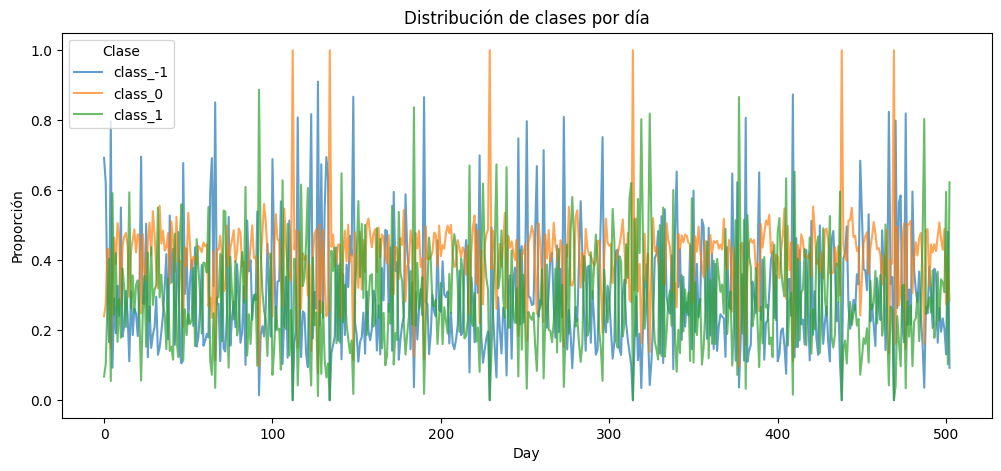

In [28]:
import matplotlib.pyplot as plt
target_by_day.plot(figsize=(12, 5),alpha=0.7)
plt.title("Distribución de clases por día")
plt.xlabel("Day")
plt.ylabel("Proporción")
plt.legend(title="Clase")
plt.show()

### Conclusiones de la auditoría del target

La auditoría de la variable objetivo `reod` permite establecer varios resultados relevantes para el diseño posterior del experimento.

#### 1. Existe un desbalance moderado de clases

La distribución global del target es:

- `reod = -1`: aproximadamente **30.08%**
- `reod = 0`: aproximadamente **41.19%**
- `reod = +1`: aproximadamente **28.72%**

La clase neutral (`0`) es, por tanto, la categoría más frecuente. Sin embargo, las dos clases direccionales mantienen una representación considerable y relativamente simétrica entre sí.

Esto implica que el problema no presenta un desbalance extremo, aunque utilizar únicamente accuracy podría ocultar diferencias importantes en la capacidad del modelo para identificar correctamente las clases direccionales.

#### 2. El majority-class baseline es aproximadamente 41.2%

Un clasificador que predijera sistemáticamente:

$$
\hat{Y}=0
$$

obtendría aproximadamente:

$$
Accuracy_{majority}\approx41.2\%
$$

Por lo tanto, este valor constituye un baseline mínimo más relevante que el 33% asociado a una clasificación aleatoria entre tres clases balanceadas.

El benchmark de 41.74% reportado por el challenge se encuentra sólo ligeramente por encima de este baseline, por lo que una mejora en accuracy deberá evaluarse cuidadosamente para determinar si realmente proviene de capacidad predictiva sobre las clases direccionales.

#### 3. La composición de clases cambia considerablemente entre días

Aunque la distribución agregada del target parece relativamente equilibrada, el análisis por día revela una heterogeneidad considerable.

Las desviaciones estándar de las proporciones diarias son aproximadamente:

$$
\sigma_{-1}=0.171,\qquad
\sigma_{0}=0.111,\qquad
\sigma_{+1}=0.155
$$

Además, existen días extremos en los que una gran proporción de las equities pertenece a una misma clase. Por ejemplo, la proporción diaria de la clase `-1` alcanza aproximadamente 91%, mientras que la clase `+1` llega aproximadamente a 89%.

La clase neutral presenta menor variabilidad entre días, aunque también existen jornadas excepcionales en las que prácticamente todas las observaciones pertenecen a `reod = 0`.

Por lo tanto:

$$
P(Y=k\mid day)
$$

no parece constante a través del tiempo.

#### 4. El día parece representar una fuente relevante de heterogeneidad común

La variación conjunta de las clases entre equities pertenecientes al mismo día sugiere que el target no depende exclusivamente del comportamiento idiosincrático de cada activo.

Existen jornadas predominantemente negativas, positivas o neutrales, lo que es consistente con la posible existencia de un componente común de mercado o de régimen diario.

Este resultado todavía **no demuestra capacidad predictiva**, ya que únicamente estamos analizando la distribución del target.

Sin embargo, sí motiva una hipótesis que deberá investigarse posteriormente: el estado cross-sectional del mercado observado antes de las 14:00 podría contener información relevante para predecir la distribución de `reod` durante las últimas dos horas.

### Implicación para el diseño experimental

Los resultados anteriores refuerzan dos decisiones metodológicas:

1. La evaluación posterior no debería depender exclusivamente de accuracy. Será conveniente complementar esta métrica con medidas como `macro-F1`, `balanced accuracy` y matrices de confusión.

2. La estructura por día deberá respetarse durante la validación. Una separación aleatoria de observaciones podría permitir que el modelo observe durante entrenamiento otras equities pertenecientes al mismo régimen diario que aparece en validation, generando una estimación demasiado optimista de su capacidad de generalización.

En consecuencia, la dimensión `day` no debe considerarse únicamente como un identificador administrativo, sino como una dimensión estructural relevante del problema.

## <b> 5. Calidad de datos y valores faltantes </b>

Una vez validada la integridad estructural del dataset y la distribución de la variable objetivo, se analizará la calidad de las 53 variables de retornos intradía.

Esta sección se concentra en cuatro aspectos:

1. magnitud global de los valores faltantes;
2. distribución del missingness a lo largo de la sesión;
3. diferencia entre valores faltantes y retornos exactamente iguales a cero;
4. comparación de estos patrones entre training y test.

El objetivo es identificar posibles diferencias estructurales entre ambos conjuntos antes de definir cualquier estrategia de imputación o preprocesamiento.

In [29]:
# 5.1 Magnitud global del missingness

def missing_summary(df, return_cols):
    returns = df[return_cols]

    return pd.Series({
        "total_values": returns.size,
        "missing_values": returns.isna().sum().sum(),
        "missing_pct": returns.isna().mean().mean() * 100,
        "rows_with_missing": returns.isna().any(axis=1).sum(),
        "rows_with_missing_pct": returns.isna().any(axis=1).mean() * 100,
        "rows_all_missing": returns.isna().all(axis=1).sum()
    })


missing_comparison = pd.DataFrame({
    "train": missing_summary(input_train, return_cols),
    "test": missing_summary(input_test, return_cols)
})

missing_comparison

,train,test
total_values,4.469485e+07,4.694735e+07
missing_values,4.812720e+06,1.399216e+06
missing_pct,1.076795e+01,2.980394e+00
rows_with_missing,2.423630e+05,1.119430e+05
rows_with_missing_pct,2.873987e+01,1.263752e+01
rows_all_missing,1.996000e+03,4.000000e+02


### Magnitud global de los valores faltantes

Los retornos intradía presentan valores faltantes tanto en training como en test. Sin embargo, su frecuencia es considerablemente diferente entre ambos conjuntos.

En training, aproximadamente el 10.8% de los valores de `r0,...,r52` son faltantes, mientras que en test esta proporción se reduce aproximadamente al 3.0%.

Asimismo, cerca del 28.7% de las observaciones de training contienen al menos un retorno faltante, frente a aproximadamente 12.6% en test.

Esta diferencia constituye una primera evidencia de **distribution shift en el mecanismo de observación de los datos**.

Por el momento no se realizará ninguna imputación, ya que primero es necesario entender la estructura temporal de estos valores faltantes.

### 5.2 ¿Dónde aparecen los NaN dentro de la sesión?

In [30]:
missing_by_return = pd.DataFrame({"train": input_train[return_cols].isna().mean() * 100,"test": input_test[return_cols].isna().mean() * 100})
missing_by_return.head()

,train,test
r0,5.433779,2.993230
r1,11.480507,2.961507
r2,12.151088,2.893320
r3,11.166739,2.754349
r4,11.114682,2.590655


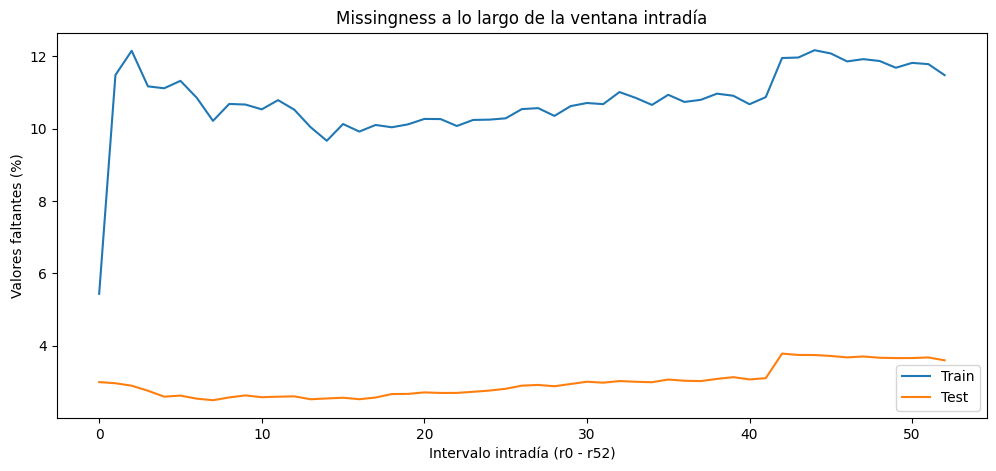

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.plot(range(53),missing_by_return["train"],label="Train")
plt.plot(range(53),missing_by_return["test"],label="Test")
plt.xlabel("Intervalo intradía (r0 - r52)")
plt.ylabel("Valores faltantes (%)")
plt.title("Missingness a lo largo de la ventana intradía")
plt.legend()
plt.show()

### Distribución temporal de los valores faltantes

El análisis de los valores faltantes a través de los 53 intervalos muestra que el `missingness` no se concentra únicamente en una región específica de la ventana intradía.

En training, después de un nivel relativamente bajo en `r0` (aproximadamente 5.4%), la proporción de valores faltantes aumenta rápidamente y se mantiene aproximadamente entre 10% y 12% durante la mayor parte de la sesión.

En test, el nivel de `missingness` es considerablemente menor y permanece aproximadamente entre 2.5% y 3.2% durante gran parte de la ventana, con un incremento moderado hacia los últimos intervalos.

La diferencia entre ambos conjuntos es persistente a través de prácticamente toda la secuencia:

$$
MissingRate_{train,t} > MissingRate_{test,t}
$$

para la gran mayoría de los intervalos $t$.

Por lo tanto, la diferencia global de valores faltantes entre training y test no parece estar causada por uno o varios intervalos aislados, sino por una diferencia estructural en el patrón de observación de ambos conjuntos.

Adicionalmente, el `missingness` presenta cierta estructura temporal dentro de cada dataset, particularmente al inicio y hacia los últimos intervalos. Sin embargo, con la información disponible no es posible determinar el mecanismo económico o de construcción de datos que genera estos valores faltantes.

Este resultado refuerza la decisión de no realizar una imputación automática en esta etapa y de conservar explícitamente la información sobre qué retornos fueron observados y cuáles se encuentran ausentes.

### 5.3 Retorno cero ≠ NaN

También sabemos que existen muchísimos retornos exactamente iguales a cero.

Cuantifiquémoslos correctamente excluyendo NaN:

In [32]:
def zero_summary(df, return_cols):
    returns = df[return_cols]

    observed = returns.notna().sum().sum()
    zeros = returns.eq(0).sum().sum()

    return pd.Series({"observed_values": observed,"zero_returns": zeros,"zero_pct_observed": zeros / observed * 100})

zero_comparison = pd.DataFrame({"train": zero_summary(input_train, return_cols),"test": zero_summary(input_test, return_cols)})
zero_comparison

,train,test
observed_values,3.988213e+07,4.554813e+07
zero_returns,9.368274e+06,8.169706e+06
zero_pct_observed,2.348991e+01,1.793642e+01


### Retornos iguales a cero y valores faltantes

Los valores faltantes y los retornos exactamente iguales a cero representan estados distintos dentro del dataset y, por lo tanto, no deben tratarse como equivalentes.

Entre los retornos efectivamente observados, aproximadamente:

$$
P(r_t=0 \mid r_t\text{ observado}) =
23.49\%
$$

en training, mientras que en test esta proporción disminuye a aproximadamente:

$$
17.94\%
$$

Esto muestra que los retornos iguales a cero representan una fracción considerable de las observaciones y no constituyen un fenómeno marginal.

Al combinar este resultado con el análisis previo de valores faltantes se observan dos diferencias estructurales entre training y test:

$$
MissingRate_{train} \approx 10.77\%
\qquad vs. \qquad
MissingRate_{test} \approx 2.98\%
$$

y

$$
P(r_t=0\mid observed)_{train} \approx 23.49\%
\qquad vs. \qquad
P(r_t=0\mid observed)_{test} \approx 17.94\%
$$

Por lo tanto, training y test difieren tanto en la frecuencia de observaciones ausentes como en la frecuencia de retornos observados exactamente iguales a cero.

En consecuencia:

$$
r_t=0 \neq r_t=NaN
$$

y una imputación directa de los valores faltantes mediante cero eliminaría esta distinción y modificaría artificialmente una característica que ya presenta diferencias relevantes entre training y test.

Con la información disponible no se atribuirá todavía una interpretación económica específica a ninguno de estos patrones. Su posible relación con liquidez, frecuencia de negociación u otras características del mercado deberá considerarse únicamente como una hipótesis para análisis posteriores.

### 5.4 Caracterizar el missingness por observación
Queremos entender si tenemos muchas filas con uno o dos NaN o si existen secuencias fuertemente incompletas.

In [34]:
train_missing_count = (
    input_train[return_cols]
    .isna()
    .sum(axis=1)
)

test_missing_count = (
    input_test[return_cols]
    .isna()
    .sum(axis=1)
)

missing_per_row = pd.DataFrame({
    "train": train_missing_count.describe(),
    "test": test_missing_count.describe()
})

missing_per_row

,train,test
count,843299.000000,885799.000000
mean,5.707015,1.579609
std,12.213529,6.158295
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,2.000000,0.000000
max,53.000000,53.000000


In [35]:
quantiles = [0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]

missing_row_quantiles = pd.DataFrame({
    "train": train_missing_count.quantile(quantiles),
    "test": test_missing_count.quantile(quantiles)
})

missing_row_quantiles

,train,test
0.00,0.0,0.0
0.25,0.0,0.0
0.50,0.0,0.0
0.75,2.0,0.0
0.90,26.0,2.0
0.95,38.0,11.0
0.99,50.0,36.0
1.00,53.0,53.0


### Conclusiones de la calidad de datos

La auditoría de los retornos intradía identifica una diferencia estructural clara entre training y test.

En particular:

1. Training presenta una proporción considerablemente mayor de valores faltantes que test (aproximadamente 10.77% frente a 2.98%).

2. Esta diferencia persiste a lo largo de prácticamente toda la ventana intradía, por lo que no parece estar causada por un intervalo aislado.

3. Los retornos exactamente iguales a cero también son frecuentes y presentan una distribución diferente entre ambos conjuntos: aproximadamente 23.49% de los retornos observados en training frente a 17.94% en test.

4. El missingness se encuentra fuertemente concentrado en la cola de la distribución. La mayoría de las observaciones contiene pocos o ningún valor faltante, mientras que un subconjunto relativamente pequeño presenta trayectorias altamente incompletas.

En consecuencia, training y test presentan diferencias observables en la estructura de las secuencias:

$$
P_{train}(missingness,\; r_t=0)
\neq
P_{test}(missingness,\; r_t=0)
$$

Esto proporciona evidencia de un **distribution shift observable en las características de los inputs**, aunque todavía no permite determinar su origen económico.

Por esta razón, durante esta etapa no se realizará una imputación definitiva. Los valores faltantes y los retornos iguales a cero permanecerán conceptualmente separados hasta evaluar estrategias de preprocesamiento dentro del framework de validación.

## 6. Especificación final del problema y restricciones experimentales

La auditoría realizada permite establecer la especificación final del problema y las principales restricciones que deberán respetarse durante las siguientes etapas del proyecto.

### 6.1 Especificación final

La unidad de observación del problema es una combinación única:

$$
(day, equity)
$$

Para cada observación se dispone de una trayectoria de 53 retornos de 5 minutos entre las 09:30 y las 14:00:

$$
X_{i,d} =
[r_{i,d,0},\dots,r_{i,d,52}]
$$

y se busca predecir el régimen direccional del retorno entre las 14:00 y las 16:00:

$$
Y_{i,d}\in\{-1,0,+1\}
$$

El problema puede expresarse como:

$$
f(\mathcal{I}_{i,d,t\leq14:00})
\rightarrow
P(Y_{i,d}=-1),\;
P(Y_{i,d}=0),\;
P(Y_{i,d}=+1)
$$

donde $\mathcal{I}_{i,d,t\leq14:00}$ representa exclusivamente información disponible hasta el momento de predicción.

El conjunto final de test representa un escenario particularmente exigente de generalización, ya que contiene tanto días como equities completamente diferentes a los utilizados durante training:

$$
D_{train}\cap D_{test}=\varnothing
$$

$$
E_{train}\cap E_{test}=\varnothing
$$

Por lo tanto, el objetivo será identificar patrones intradía transferibles y no comportamientos específicos asociados a determinados identificadores.

### 6.2 Restricciones para el diseño experimental

A partir de los resultados de la auditoría se establecen las siguientes reglas para las etapas posteriores del proyecto:

**1. Frontera temporal**

Ninguna variable podrá utilizar información posterior a las 14:00.

Toda transformación, agregación cross-sectional o feature deberá satisfacer:

$$
\mathcal{I}_{feature}\subseteq\mathcal{I}_{t\leq14:00}
$$

con el objetivo de evitar `look-ahead bias`.

**2. Validación compatible con el escenario OOS**

No se utilizará un `random train-test split` a nivel de filas como mecanismo principal de validación.

El framework de validación deberá evaluar la capacidad de generalización hacia días y equities no observados, reproduciendo en la medida de lo posible la separación existente entre training y test.

**3. Los identificadores no representan variables continuas**

`ID`, `day` y `equity` no serán introducidos directamente como variables numéricas continuas en los modelos.

`day` y `equity` podrán utilizarse para preservar la estructura del panel y construir información válida, siempre respetando la frontera temporal.

**4. NaN y retorno cero permanecerán diferenciados**

La auditoría mostró que:

$$
r_t=0 \neq r_t=NaN
$$

y que sus frecuencias presentan diferencias importantes entre training y test.

Por lo tanto, no se realizará una sustitución automática de los valores faltantes por cero. Cualquier estrategia de imputación deberá evaluarse posteriormente dentro del framework de validación.

**5. El benchmark mínimo será el majority-class baseline**

Debido al desbalance moderado de `reod`, predecir sistemáticamente la clase `0` produce aproximadamente:

$$
Accuracy_{majority}\approx41.2\%
$$

Por lo tanto, este resultado se utilizará como baseline mínimo junto con el benchmark oficial del challenge.

La evaluación posterior no dependerá exclusivamente de accuracy. También se considerarán métricas sensibles al desempeño entre clases, como `macro-F1`, `balanced accuracy` y matrices de confusión.

### 6.3 Conclusión de la auditoría

La auditoría confirma que el dataset es estructuralmente consistente y permite formular el challenge como un problema de clasificación de trayectorias financieras intradía bajo un escenario fuerte de generalización fuera de muestra.

Se identificaron tres características especialmente relevantes para las siguientes etapas:

1. **Heterogeneidad temporal del target:** la distribución de `reod` cambia considerablemente entre días, sugiriendo la presencia de un componente común o régimen diario que deberá investigarse posteriormente.

2. **Distribution shift observable:** training y test presentan diferencias importantes en la frecuencia y estructura temporal de valores faltantes y retornos iguales a cero.

3. **Generalización hacia nuevos activos y periodos:** test contiene días y equities completamente no observados durante training, por lo que la validación deberá diseñarse explícitamente alrededor de esta característica.

Hasta este punto no se ha intentado identificar señal predictiva ni se han realizado transformaciones destinadas a mejorar el desempeño de un modelo.

La siguiente etapa del research buscará responder una pregunta diferente:

> **¿Qué características de la trayectoria observada entre 09:30 y 14:00 contienen información sobre el régimen direccional posterior?**

Esta pregunta será abordada en:

`01_eda_and_signal_hypotheses.ipynb`